**Assignment 2**


**Question 1**



First we import our needed packages and load the data

In [1]:
import torch
import math
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=0.5, std=1.0)])
train_dataset = datasets.MNIST(root='../data', train=True,
                               download=True, transform=transform)
test_dataset = datasets.MNIST(root='../data', train=False,
                              download=True, transform=transform)


We then transform our tensors to be the correct size (60000, 784) and also centre the columns of X.

In [2]:
X = train_dataset.data.float().reshape(len(train_dataset), -1)
column_means = X.mean(dim=0, keepdim=True)
X -= column_means
print(X.shape)


torch.Size([60000, 784])


We can now compute the SVD of X

In [3]:
U, S, Vh = torch.linalg.svd(X, full_matrices=False)
print("Shape of U, S and Vh:\n", U.shape, S.shape, Vh.shape)

Shape of U, S and Vh:
 torch.Size([60000, 784]) torch.Size([784]) torch.Size([784, 784])


After computing the SVD of X we can now pull out the first 2 principal directions from our Matrix V

In [4]:
# First two principal directions
V_2 = Vh[:2, :].T           # shape: [784, 2]

# PCA coordinates for every image
X_pca = X @ V_2    # shape: [60000, 2]

print(X_pca.shape)

torch.Size([60000, 2])


And then plot them as so:

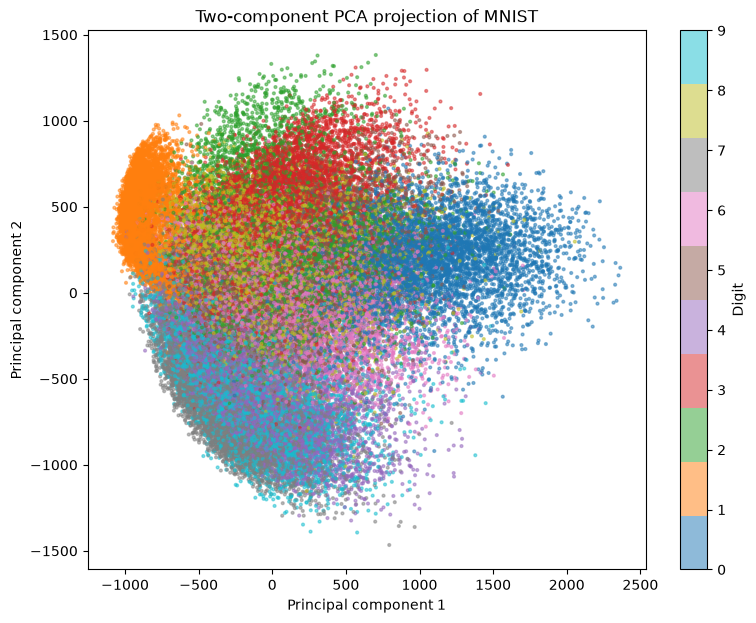

In [5]:
labels = train_dataset.targets


plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_pca[:, 0].cpu(),
    X_pca[:, 1].cpu(),
    c=labels.cpu(),
    cmap="tab10",
    s=4,
    alpha=0.5
)

plt.colorbar(scatter, label="Digit")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Two-component PCA projection of MNIST")
plt.show()

In this plot of the 2 principal components of our data whilst there is a lot of data and a fair amount of crossover you can also see that each digit is largely clustered similarly with their other digits. 

(0.0, 100000.0)

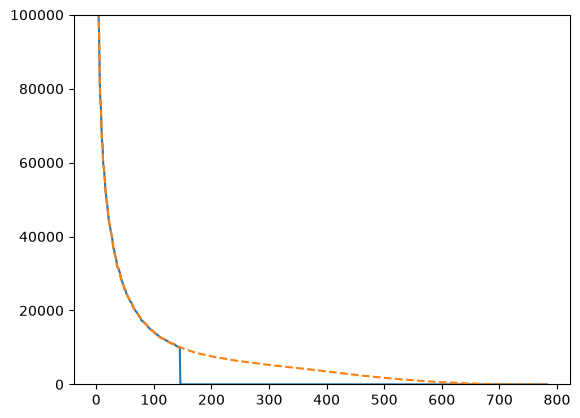

In [6]:
import copy

threshold = 10000.0
S2 = copy.deepcopy(S)
S2[S < threshold] = 0.0

plt.plot(S2)
plt.plot(S, linestyle='dashed')
plt.ylim([0, 100000])


Is there an "elbow"; or equivalently, do a small number of singular values explain most of the variance in the data?

With reference to your answer to the previous part, explain whether PCA could be used to form a low dimensional representation of the dataset.

**Question 2**

**Question 3**

**Question 4**